In [7]:
import sys
import importlib
sys.path.append('../../')  # Adjust the path as needed

import utilities.functions as functions
import utilities.explore as explore
import utilities.plot as plot

# Reload the module to reflect the changes
importlib.reload(functions)
importlib.reload(explore)
importlib.reload(plot)
IN_seq_path = '../IN/data/in.reduce4.seq'
PR_seq_path = '../PR/data/pr.exper.reduce4.seq'    
RT_seq_path = '../RT/data/rt.reduce4.seq'

IN_all_seq = functions.read_seq(IN_seq_path)
PR_all_seq = functions.read_seq(PR_seq_path)
RT_all_seq = functions.read_seq(RT_seq_path)

IN_consensus = '../IN/data/in.consensus.reduce4.seq'
with open(IN_consensus, 'r') as f:
    IN_consensus_seq = f.read().strip()
# print("IN consensus sequence:", IN_consensus_seq)
PR_consensus = '../PR/data/pr.consensus.reduce4.seq'
with open(PR_consensus, 'r') as f:
    PR_consensus_seq = f.read().strip()
RT_consensus = '../RT/data/rt.consensus.reduce4.seq'
with open(RT_consensus, 'r') as f:
    RT_consensus_seq = f.read().strip()

# print(IN_consensus_seq)
    
IN_redux = functions.get_redu_dict('../IN/data/in.reduce4.redux',1)
PR_redux = functions.get_redu_dict('../PR/data/pr.reduce4.redux',0)
RT_redux = functions.get_redu_dict('../RT/data/rt.reduce4.redux',0)

IN_J = functions.load_J_dict('../IN/data/J.npy',1,263)
PR_J = functions.load_J_dict('../PR/data/J_PR.npy',1,99)
RT_J = functions.load_J_dict('../RT/data/J_RT.npy',39,226)

IN_all_seq_unreduced = functions.read_seq('../IN/data/in.fullseq')
PR_all_seq_unreduced = functions.read_seq('../PR/data/pr.exper.fullseq')
RT_all_seq_unreduced = functions.read_seq('../RT/data/rt.fullseq')

In [8]:
# Correct file paths for reading probability CSV files
# v14 merges the RT NRTI and NNRTI pair lists into one file, so RT is a single series here
IN_csv_path = 'integrase_all_probabilities_v16.csv'
PR_csv_path = 'protease_all_probabilities_v16.csv'
RT_csv_path = 'reverseTranscriptase_both_probabilities_v16.csv'

# Load CSV files
import pandas as pd
df_IN = pd.read_csv(IN_csv_path)
df_PR = pd.read_csv(PR_csv_path)
df_RT = pd.read_csv(RT_csv_path)

print('All CSV files loaded successfully')

All CSV files loaded successfully


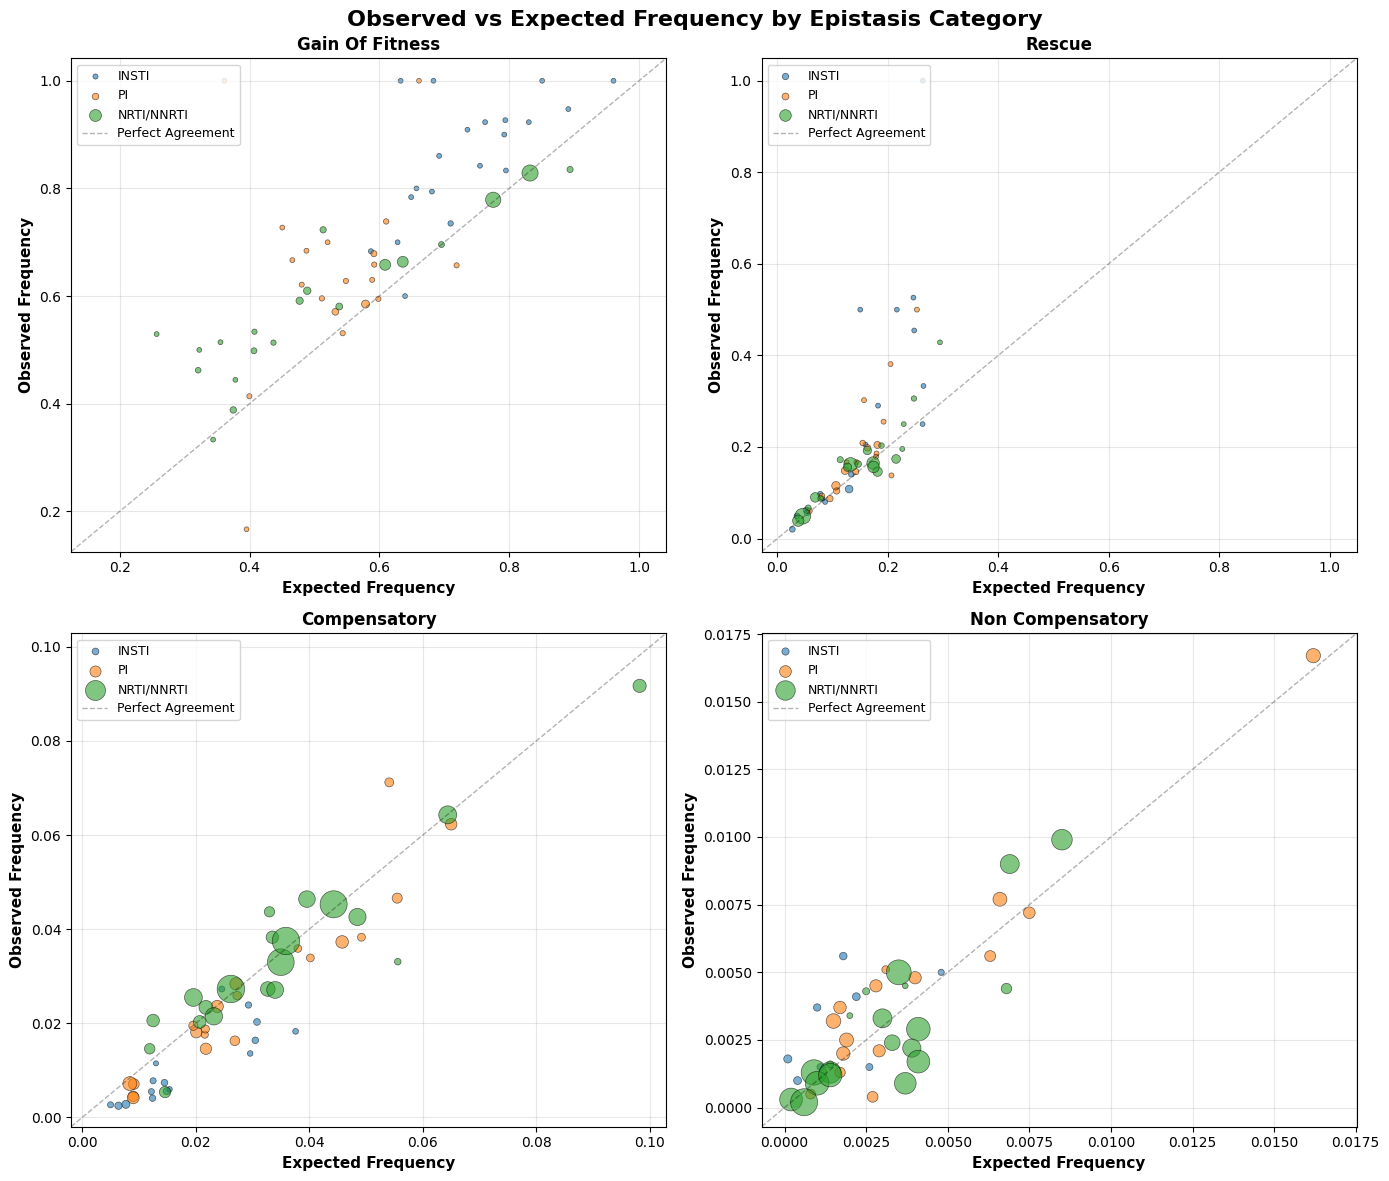

Plot saved as observed_vs_expected_plot.png


In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Modify the scatter plot to scale point size by num_seqs
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Observed vs Expected Frequency by Epistasis Category', fontsize=16, fontweight='bold')

categories = ['Gain_of_function', 'rescue', 'compensatory', 'non_compensatory']
drugs = [
    {'name': 'INSTI', 'df': df_IN, 'color': '#1f77b4', 'size': 1220},
    {'name': 'PI', 'df': df_PR, 'color': '#ff7f0e', 'size': 5710},
    {'name': 'NRTI/NNRTI', 'df': df_RT, 'color': '#2ca02c', 'size': 19194}
]

positions = [(0, 0), (0, 1), (1, 0), (1, 1)]

for cat_idx, category in enumerate(categories):
    category_title = category.replace('_', ' ').title()
    if category == 'Gain_of_function':
        category_title = 'Gain of Fitness'
    ax = axes[positions[cat_idx][0], positions[cat_idx][1]]
    
    for drug in drugs:
        df_cat = drug['df'][drug['df']['epistasis_subset'] == category]
        df_cat = df_cat.dropna(subset=['average_p_subcategory', 'observed_f_subcategory'])
        df_cat = df_cat[
        (df_cat['average_p_subcategory'] != 0) &
        (df_cat['observed_f_subcategory'] != 0)
        ]
        
        if len(df_cat) > 0:
            # Scale size by num_seqs (normalize to reasonable marker size)
            # print( drug['size'])
            sizes = (df_cat['num_seqs'] / 10000) * 200+12
            # print(sizes)
            
            ax.scatter(
                df_cat['average_p_subcategory'],
                df_cat['observed_f_subcategory'],
                label=drug['name'],
                color=drug['color'],
                alpha=0.6,
                s=sizes,
                edgecolors='black',
                linewidth=0.5
            )
    
    ax.set_xlabel('Expected Frequency', fontsize=11, fontweight='bold')
    ax.set_ylabel('Observed Frequency', fontsize=11, fontweight='bold')
    ax.set_title(category_title.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    
    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]),
        np.max([ax.get_xlim(), ax.get_ylim()]),
    ]
    ax.plot(lims, lims, 'k--', alpha=0.3, linewidth=1, label='Perfect Agreement')
    
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('observed_vs_expected_plot.png', dpi=300, bbox_inches='tight')
plt.show()
print('Plot saved as observed_vs_expected_plot.png')
